# Initial Weather Data Exploration

Eksplorasi awal karakteristik data cuaca di sekitar FILKOM Universitas Brawijaya untuk proyek prediksi hujan tiga jam ke depan.

In [1]:
import httpx
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
URL = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": -7.9666,
    "longitude": 112.6326,
    "start_date": "2026-08-01",
    "end_date": "2026-08-07",
    "hourly": [
        "temperature_2m",
        "relative_humidity_2m",
        "precipitation",
        "rain",
        "cloud_cover",
        "wind_speed_10m",
        "wind_direction_10m",
        "pressure_msl",
    ],
    "timezone": "Asia/Jakarta",
}

response = httpx.get(URL, params=params, timeout=30)
response.raise_for_status()

df = pd.DataFrame(response.json()["hourly"])
df["time"] = pd.to_datetime(df["time"])

df.head()

,time,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,wind_direction_10m,pressure_msl
0,2026-08-01 00:00:00,19.4,88,0.0,0.0,93,2.8,310,1013.1
1,2026-08-01 01:00:00,18.9,91,0.0,0.0,98,2.0,280,1013.0
2,2026-08-01 02:00:00,18.4,91,0.0,0.0,95,3.1,298,1012.8
3,2026-08-01 03:00:00,17.9,95,0.0,0.0,95,3.9,304,1012.9
4,2026-08-01 04:00:00,16.9,100,0.0,0.0,100,3.2,304,1013.2


In [3]:
print(f"Jumlah observasi: {len(df)}")
display(df.dtypes)
display(df.isna().sum())
display(df.describe())

Jumlah observasi: 168


time                    datetime64[ns]
temperature_2m                 float64
relative_humidity_2m             int64
precipitation                  float64
rain                           float64
cloud_cover                      int64
wind_speed_10m                 float64
wind_direction_10m               int64
pressure_msl                   float64
dtype: object

time                    0
temperature_2m          0
relative_humidity_2m    0
precipitation           0
rain                    0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
pressure_msl            0
dtype: int64

,time,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,wind_direction_10m,pressure_msl
count,168,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,2026-08-04 11:30:00.000000256,23.063095,74.851190,0.001786,0.001786,36.470238,4.910119,204.732143,1012.741667
min,2026-08-01 00:00:00,16.600000,38.000000,0.000000,0.000000,0.000000,0.200000,4.000000,1009.200000
25%,2026-08-02 17:45:00,20.000000,57.750000,0.000000,0.000000,12.500000,2.375000,99.250000,1011.800000
50%,2026-08-04 11:30:00,22.350000,81.500000,0.000000,0.000000,26.000000,3.900000,241.500000,1013.000000
75%,2026-08-06 05:15:00,26.725000,91.000000,0.000000,0.000000,54.750000,7.200000,306.250000,1013.700000
max,2026-08-07 23:00:00,29.500000,100.000000,0.200000,0.200000,100.000000,12.300000,357.000000,1015.800000
std,NaN,3.545032,18.311555,0.017210,0.017210,30.742688,3.090891,105.850956,1.428597


In [4]:
df["rain_next_3h_mm"] = (
    df["rain"].shift(-1)
    + df["rain"].shift(-2)
    + df["rain"].shift(-3)
)

df["rain_event_next_3h"] = df["rain_next_3h_mm"] >= 0.1

df[["time", "rain", "rain_next_3h_mm", "rain_event_next_3h"]].head(10)

,time,rain,rain_next_3h_mm,rain_event_next_3h
0,2026-08-01 00:00:00,0.0,0.0,False
1,2026-08-01 01:00:00,0.0,0.0,False
2,2026-08-01 02:00:00,0.0,0.0,False
3,2026-08-01 03:00:00,0.0,0.0,False
4,2026-08-01 04:00:00,0.0,0.0,False
5,2026-08-01 05:00:00,0.0,0.0,False
6,2026-08-01 06:00:00,0.0,0.0,False
7,2026-08-01 07:00:00,0.0,0.0,False
8,2026-08-01 08:00:00,0.0,0.0,False
9,2026-08-01 09:00:00,0.0,0.0,False


,count
rain_event,
False,164
True,4


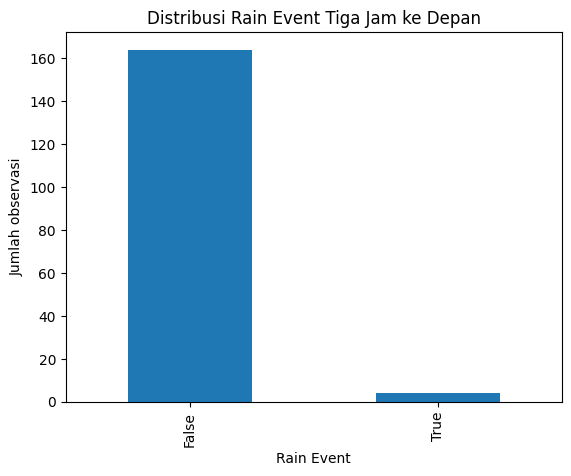

In [5]:
label_distribution = (
    df["rain_event_next_3h"]
    .value_counts(dropna=False)
    .rename_axis("rain_event")
    .to_frame("count")
)

display(label_distribution)

df["rain_event_next_3h"].value_counts().plot(
    kind="bar",
    title="Distribusi Rain Event Tiga Jam ke Depan",
)

plt.xlabel("Rain Event")
plt.ylabel("Jumlah observasi")
plt.show()